In [1]:
import matplotlib.pyplot as plt

# MD simulation to generate training data 

In [1]:
import numpy as np

np.random.seed(3)

# Reduced units for the toy double-well system
dt = 0.005
mass = 1.0                              #for the Li+ this would be about 6.94 amu, but used reduced units here
gamma = 1.0
kBT = 0.4
n_steps = 10000000
burn_in = 5000                          #steps to ignor before saving trajectory ("equilibration" ål )

# Gaussian double-well parameters
A1, x1, y1, s1 = 3.0, -1.0, 0.0, 0.5
A2, x2, y2, s2 = 3.0, 1.0, 0.0, 0.5
k_confine = 0.2                         #restoring spring constant to prevent ?explosion to infinity of what ål?


def potential(x, y):
    g1 = A1 * np.exp(-((x - x1) ** 2 + (y - y1) ** 2) / (2 * s1 ** 2))
    g2 = A2 * np.exp(-((x - x2) ** 2 + (y - y2) ** 2) / (2 * s2 ** 2))
    return -(g1 + g2) + 0.5 * k_confine * (x ** 2 + y ** 2)


def force_x(x, y):
    g1 = A1 * np.exp(-((x - x1) ** 2 + (y - y1) ** 2) / (2 * s1 ** 2))
    g2 = A2 * np.exp(-((x - x2) ** 2 + (y - y2) ** 2) / (2 * s2 ** 2))
    return -g1 * (x - x1) / s1 ** 2 - g2 * (x - x2) / s2 ** 2 - k_confine * x


def force_y(x, y):
    g1 = A1 * np.exp(-((x - x1) ** 2 + (y - y1) ** 2) / (2 * s1 ** 2))
    g2 = A2 * np.exp(-((x - x2) ** 2 + (y - y2) ** 2) / (2 * s2 ** 2))
    return -g1 * (y - y1) / s1 ** 2 - g2 * (y - y2) / s2 ** 2 - k_confine * y


# Underdamped Langevin dynamics in reduced units
x, y = -1.0, 0.0
vx, vy = 0.0, 0.0
noise_scale = np.sqrt(2 * gamma * kBT * dt) / mass
x_traj, y_traj = [], []
vx_traj, vy_traj = [], []
energy_traj = []

for step in range(n_steps):
    fx = force_x(x, y)
    fy = force_y(x, y)
    vx += (fx / mass - gamma * vx / mass) * dt + noise_scale * np.random.normal()
    vy += (fy / mass - gamma * vy / mass) * dt + noise_scale * np.random.normal()
    x += vx * dt
    y += vy * dt

    if step >= burn_in:
        x_traj.append(x)
        y_traj.append(y)
        vx_traj.append(vx)
        vy_traj.append(vy)
        energy_traj.append(potential(x, y))

positions = np.column_stack((x_traj, y_traj)).astype(np.float32)
velocities = np.column_stack((vx_traj, vy_traj)).astype(np.float32)
energy_traj = np.asarray(energy_traj, dtype=np.float32)

import datetime
date = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")    
np.savez_compressed(
    f"/Users/clarawimmelmann/Desktop/Energy_specialCourse/init_problem/train_data/double_well_data_{n_steps}steps_{date}.npz",
    positions=positions,
    velocities=velocities,
    energy=energy_traj,
)


In [2]:
# ==========================================
#calculate einstein diffuesion (Using MSD)
# ==========================================
"""
Calculates D using Mean Squared Displacement (MSD).
Formula in 2D: D = slope(MSD) / 4
"""

n_frames = positions.shape[0]
msd = np.zeros(n_frames)
    
# Calculate MSD at each frame relative to frame 0
for t in range(n_frames):
    displacement = positions[t] - positions[0]
    squared_distance = np.sum(displacement**2, axis=-1)  # Sum x^2 + y^2 + z^2
    msd[t] = np.mean(squared_distance)  # Average over all particles
        
# Generate the time array
time_array = np.arange(n_frames) * dt
    
# Linear fit to the long-time regime (the last 50% of the simulation)
# The initial part often contains short-term ballistic motion rather than diffusion
fit_start = n_frames // 2
slope, _ = np.polyfit(time_array[fit_start:], msd[fit_start:], 1)
    
# In 2D, MSD(t) = 4 D t at long times.
D_einstein = slope / 4.0


#D, msd, time_array


# ==========================================
#calculate THE GREEN-KUBO RELATION (Using VACF)
# ==========================================
"""
Calculates D using the Velocity Autocorrelation Function (VACF).
Formula in 2D: D = 1/2 * Integral(VACF)
"""
n_frames = velocities.shape[0]
vacf = np.zeros(n_frames)
    
# Efficient calculation of VACF using a sliding window
for t in range(n_frames):
    # Dot product of v(start) and v(start + t)
    v_current = velocities[0 : n_frames - t]
    v_future = velocities[t : n_frames]
        
dot_product = np.sum(v_current * v_future, axis=-1)  # v_x*v_x + v_y*v_y + v_z*v_z
vacf[t] = np.mean(dot_product)  # Average over all valid time windows and particles

# Integrate the VACF curve over time using the Trapezoidal rule
integral = np.trapezoid(vacf, dx=dt)
D_green_kubo = integral / 2.0


AttributeError: module 'numpy' has no attribute 'trapezoid'

In [ ]:
print(f"--- Diffusion Coefficient (D) Results ---")
print(f"Einstein (MSD) Method:    {D_einstein:.5f}")
print(f"Green-Kubo (VACF) Method: {D_green_kubo:.5f}")

# visualize results:

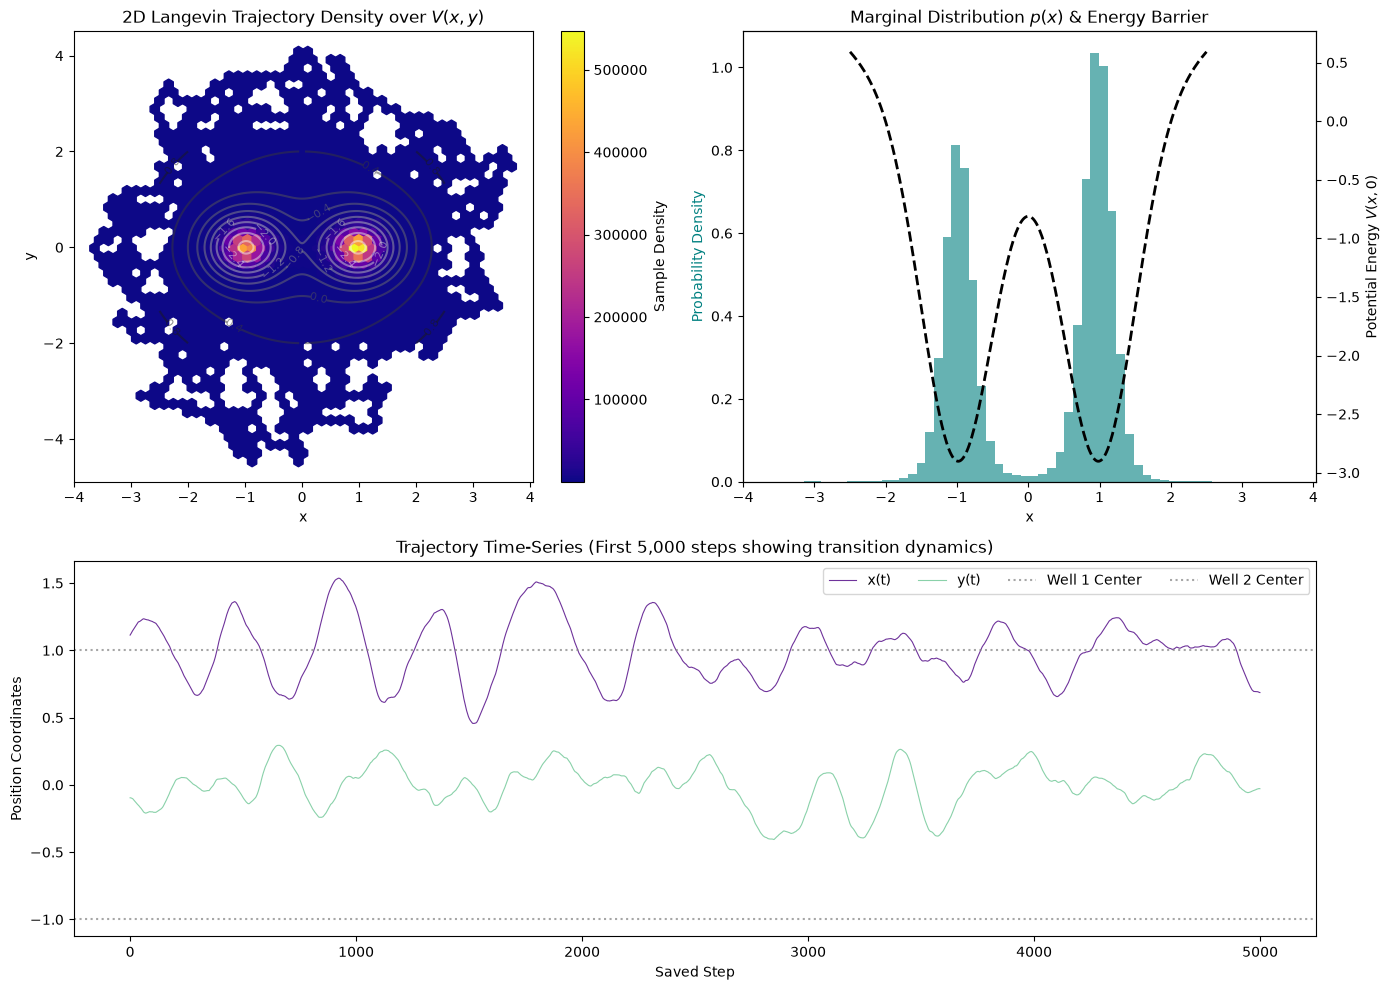

In [ ]:

# --- 2. Multi-Panel Visualization ---
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])

# Panel 1: 2D Density & Potential Energy Surface
ax1 = fig.add_subplot(gs[0, 0])
x_grid = np.linspace(-2.5, 2.5, 200)
y_grid = np.linspace(-2.0, 2.0, 200)
X, Y = np.meshgrid(x_grid, y_grid)
Z = potential(X, Y)

contour = ax1.contour(X, Y, Z, levels=12, cmap='Greys', alpha=0.5)
ax1.clabel(contour, inline=True, fontsize=8)
hb = ax1.hexbin(x_traj, y_traj, gridsize=45, cmap='plasma', mincnt=1)
fig.colorbar(hb, ax=ax1, label='Sample Density')
ax1.set_title("2D Langevin Trajectory Density over $V(x,y)$")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

# Panel 2: 1D Position Marginal vs Potential Profile
ax2 = fig.add_subplot(gs[0, 1])
ax2_twin = ax2.twinx()

# Plot x-marginal distribution
ax2.hist(x_traj, bins=60, density=True, color='teal', alpha=0.6, label='Sample Density $p(x)$')
# Overlay Potential Profile V(x, 0)
x_line = np.linspace(-2.5, 2.5, 300)
ax2_twin.plot(x_line, potential(x_line, 0.0), color='black', lw=2, linestyle='--', label='$V(x, 0)$')

ax2.set_title("Marginal Distribution $p(x)$ & Energy Barrier")
ax2.set_xlabel("x")
ax2.set_ylabel("Probability Density", color='teal')
ax2_twin.set_ylabel("Potential Energy $V(x, 0)$", color='black')

# Panel 3: Trajectory Walk (Barrier Hopping Time-Series)
ax3 = fig.add_subplot(gs[1, :])
steps = np.arange(len(x_traj))
ax3.plot(steps[:5000], x_traj[:5000], label='x(t)', color='indigo', alpha=0.8, lw=0.8)
ax3.plot(steps[:5000], y_traj[:5000], label='y(t)', color='mediumseagreen', alpha=0.6, lw=0.8)
ax3.axhline(-1.0, color='gray', linestyle=':', alpha=0.7, label='Well 1 Center')
ax3.axhline(1.0, color='gray', linestyle=':', alpha=0.7, label='Well 2 Center')

ax3.set_title("Trajectory Time-Series (First 5,000 steps showing transition dynamics)")
ax3.set_xlabel("Saved Step")
ax3.set_ylabel("Position Coordinates")
ax3.legend(loc='upper right', ncol=4)

plt.tight_layout()
plt.show()